In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import info
import loader
import stats
import plotter

dataset_path = "../dataset/processed/features.csv"
    
try:
  df = loader.load_data(dataset_path)
except FileNotFoundError as e:
  print(f"Error: dataset file ({dataset_path}) not found")
  sys.exit(1)

### Contare il numero di famiglie linguistiche, sottofamiglie, genus e lingue all'interno del dataset
Segue una visualizzazione della varietà del dataset.
La categoria tassonomica di sub-family viene utilizzata poco nel dataset, in quanto è difficile far conformare a questo schema rigido formato da 3 categorie i diversi alberi genealogici delle lingue.

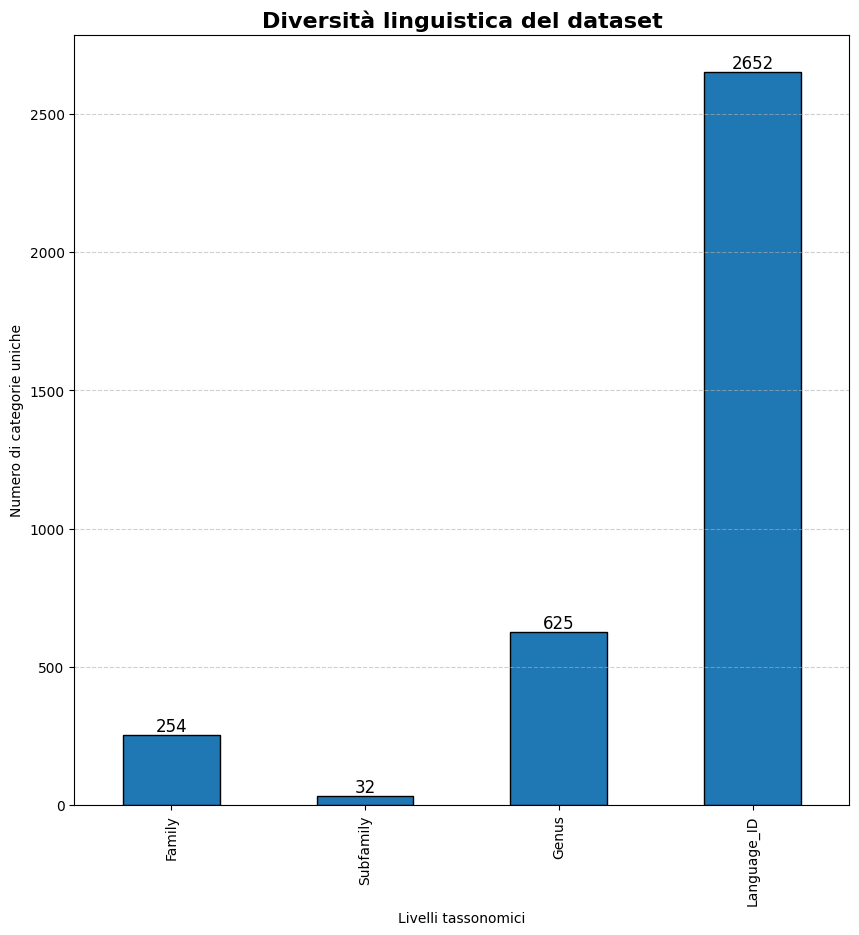

In [2]:
categories_count = df.copy()[["Family", "Subfamily", "Genus", "Language_ID"]].nunique()
categories_count
plotter.bar_plot(
  categories_count, 
  title="Diversità linguistica del dataset",
  xlabel="Livelli tassonomici",
  ylabel="Numero di categorie uniche",
  annotate=True
)

### Contare il numero di lingue per ciascuna macroarea nel dataset
Certe aree del mondo sono meno linguisticamente varie rispetto ad altre: i motivi sono molteplici e spaziano da motivi geografici, storici, politici e culturali.

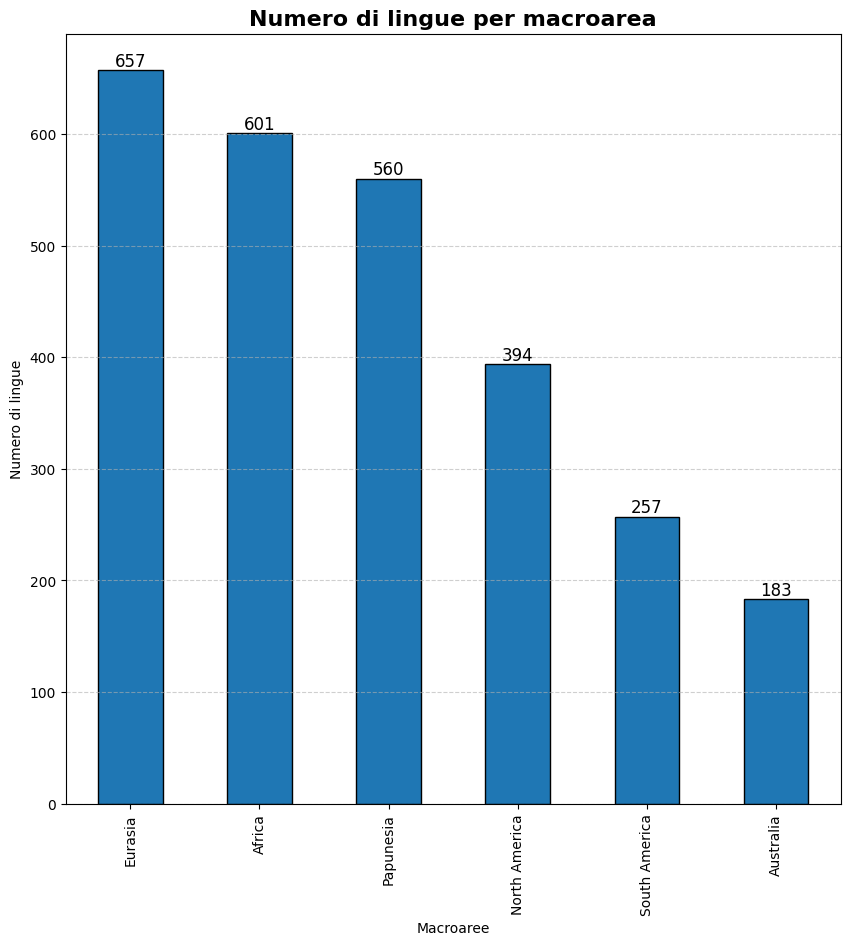

In [3]:
qdf = (
  df.copy()
  .groupby("Macroarea")["Language_ID"]
  .nunique()
  .sort_values(ascending=False)
)

plotter.bar_plot(
    qdf,
    title="Numero di lingue per macroarea",
    xlabel="Macroaree",
    ylabel="Numero di lingue",
    annotate=True
)

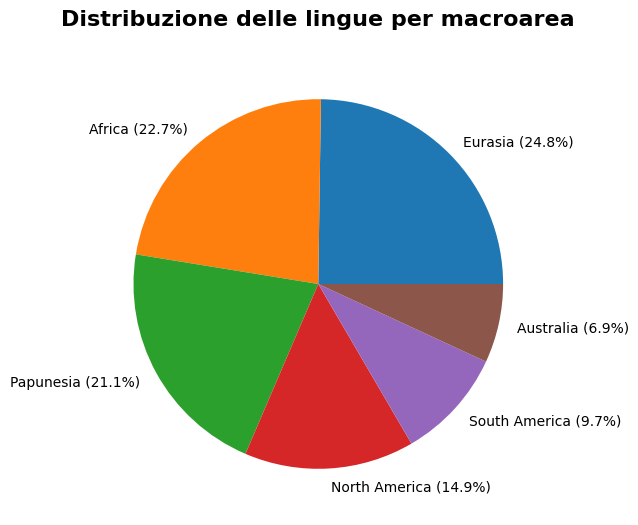

In [4]:
plotter.pie_plot(
  qdf,
  title="Distribuzione delle lingue per macroarea"
)

### Contare il numero di lingue per ciascun paese nel dataset
Lo stesso discorso si applica per i Paesi.

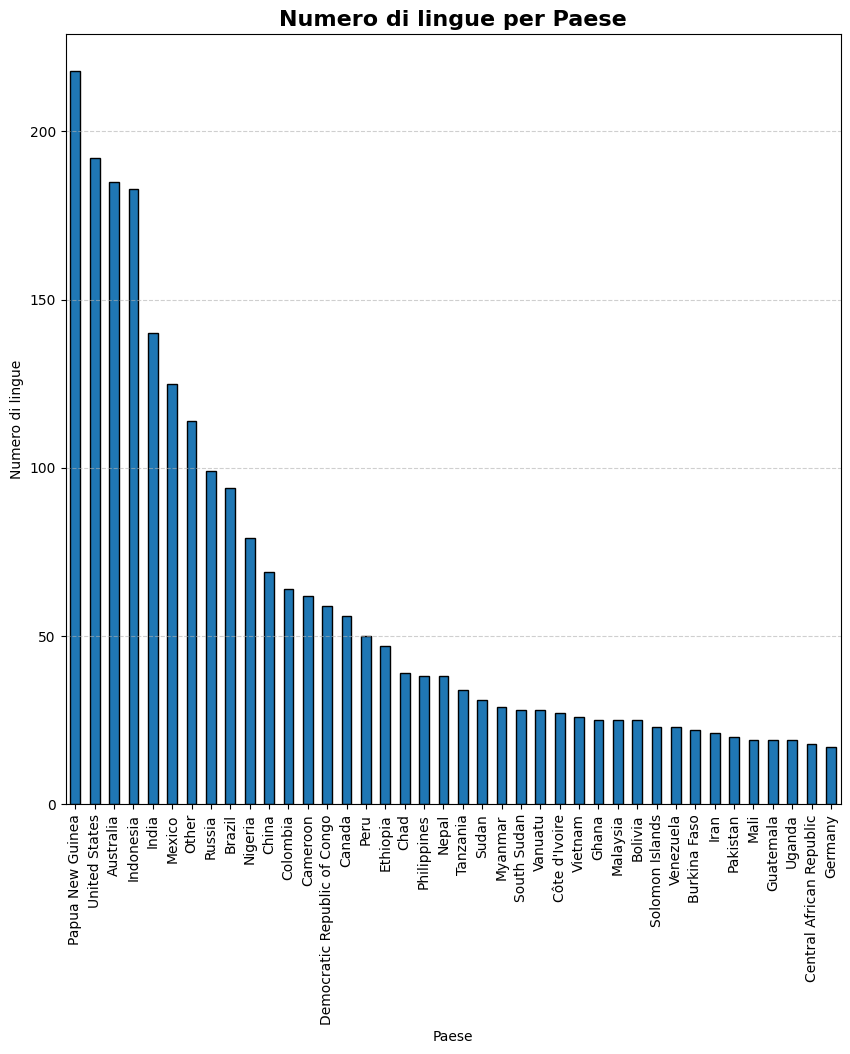

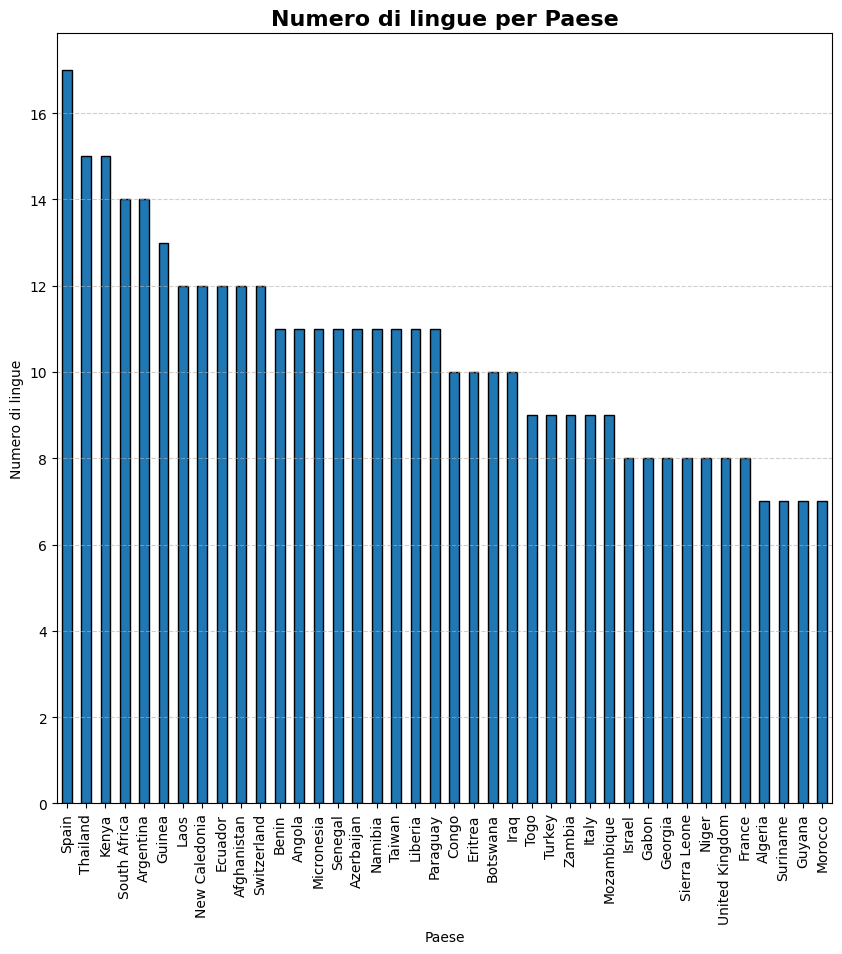

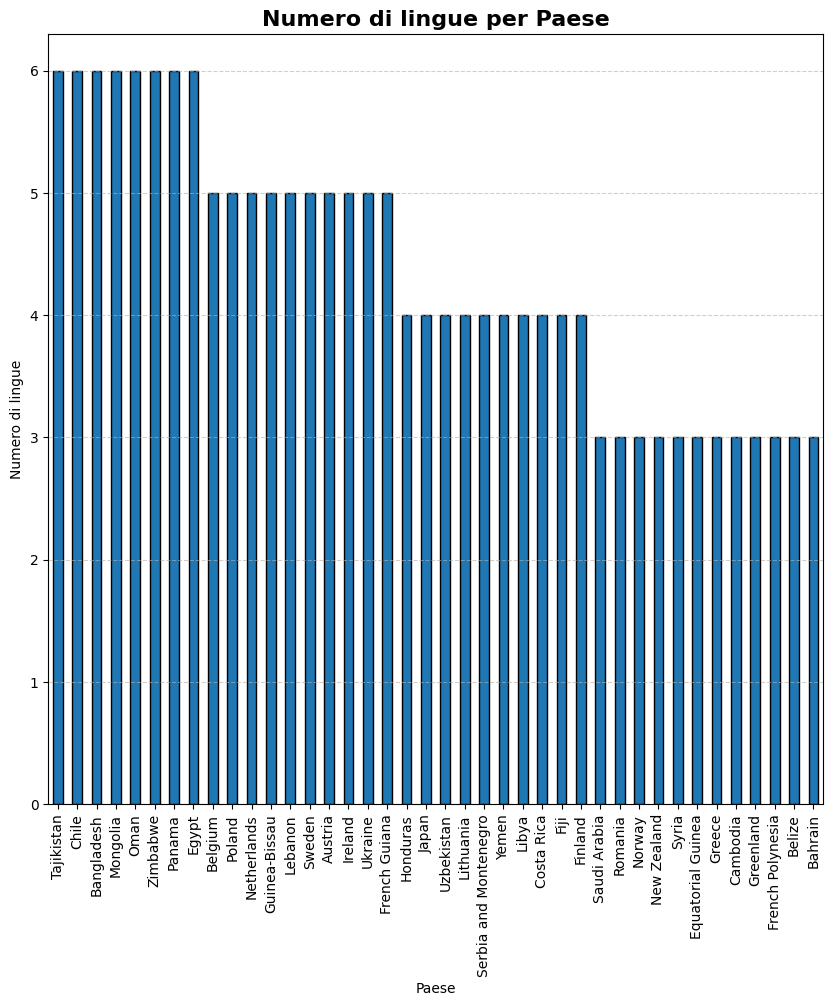

In [5]:
# TODO: Rendere questa una funzione
n_top= 119
qdf = df.copy().groupby("Country_Name")["Language_ID"].nunique().sort_values(ascending=False)

languages_by_family = stats.pack_from(qdf, n_top).sort_values(ascending=False)
languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family_chunks = stats.get_chunks(languages_by_family, (n_top + 1) // 3)

for chunk in languages_by_family_chunks:
    plotter.bar_plot(
        chunk,
        title="Numero di lingue per Paese",
        xlabel="Paese",
        ylabel="Numero di lingue",
        annotate=False
    )

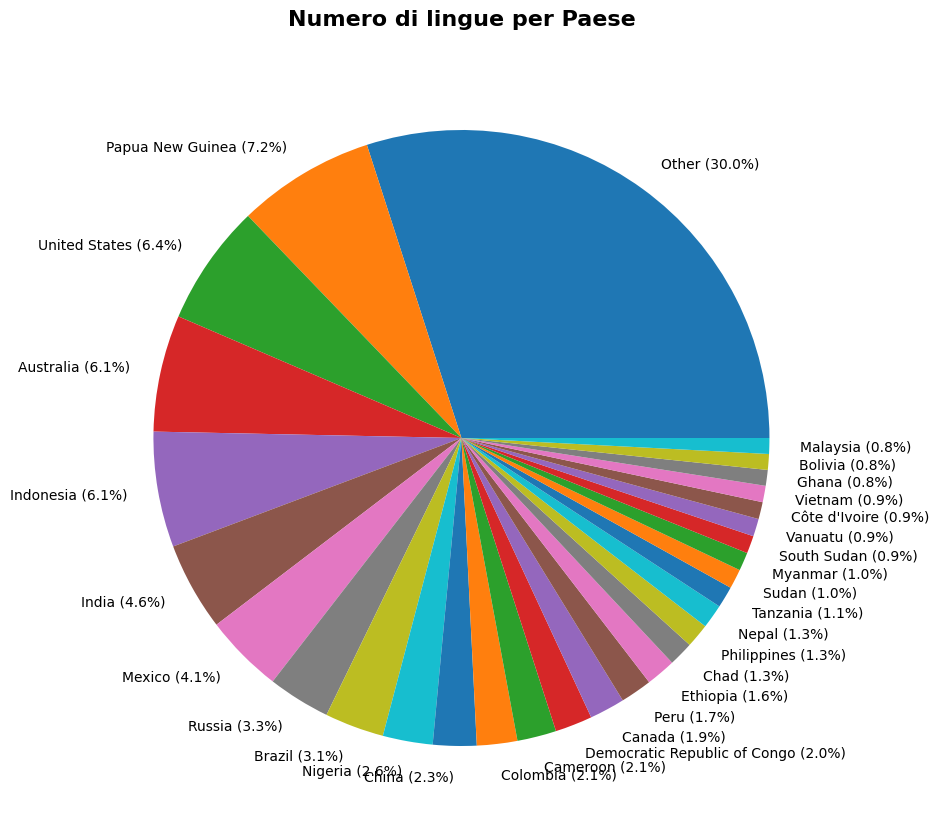

In [ ]:
n_top= 29
qdf = df.copy().groupby("Country_Name")["Language_ID"].nunique().sort_values(ascending=False)

languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family = stats.pack_from(qdf, n_top)
languages_by_family = languages_by_family.sort_values(ascending=False)

plotter.pie_plot(
  languages_by_family,
  figsize=(10, 10),
  title="Numero di lingue per Paese"
)

### Contare il numero di lingue per ciascuna famiglia linguistica nel dataset
Ovviamente esistono famiglie linguistiche più numerose di altre.

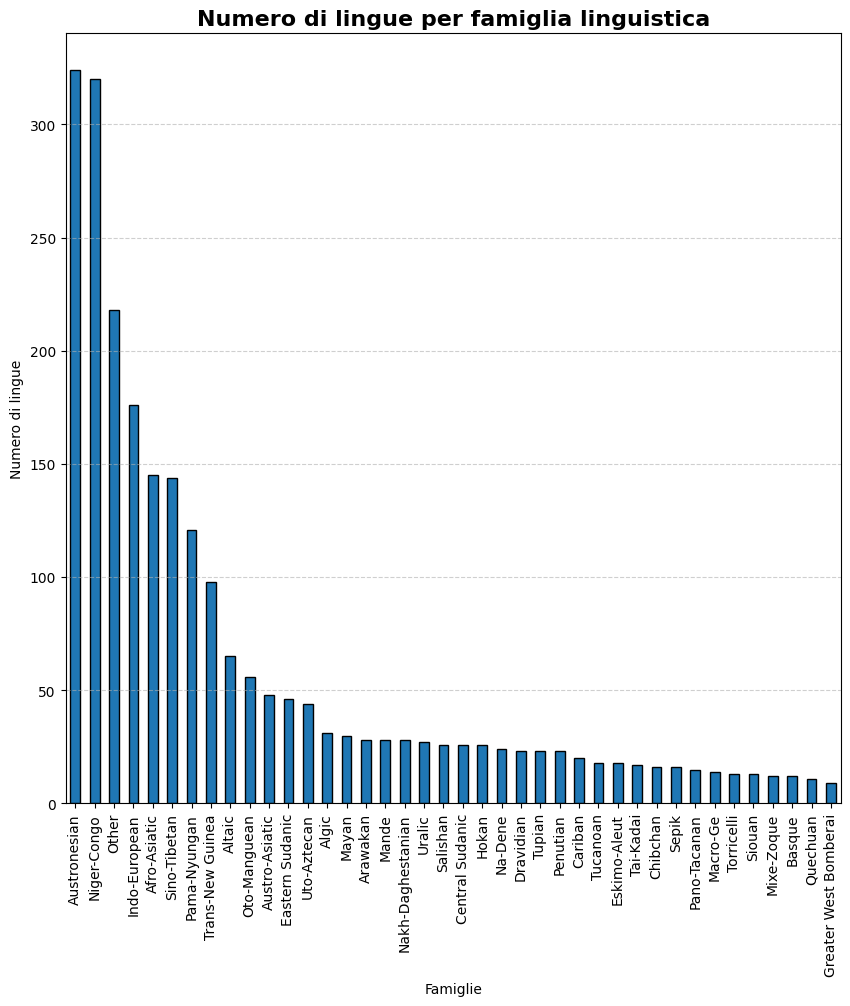

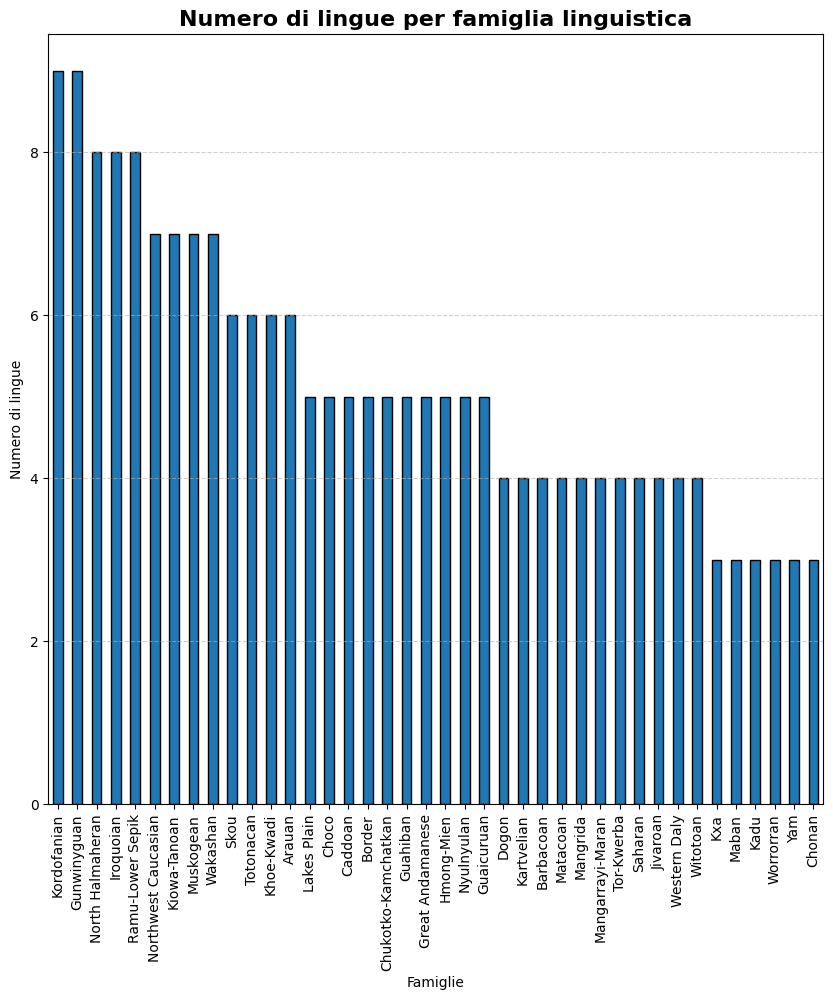

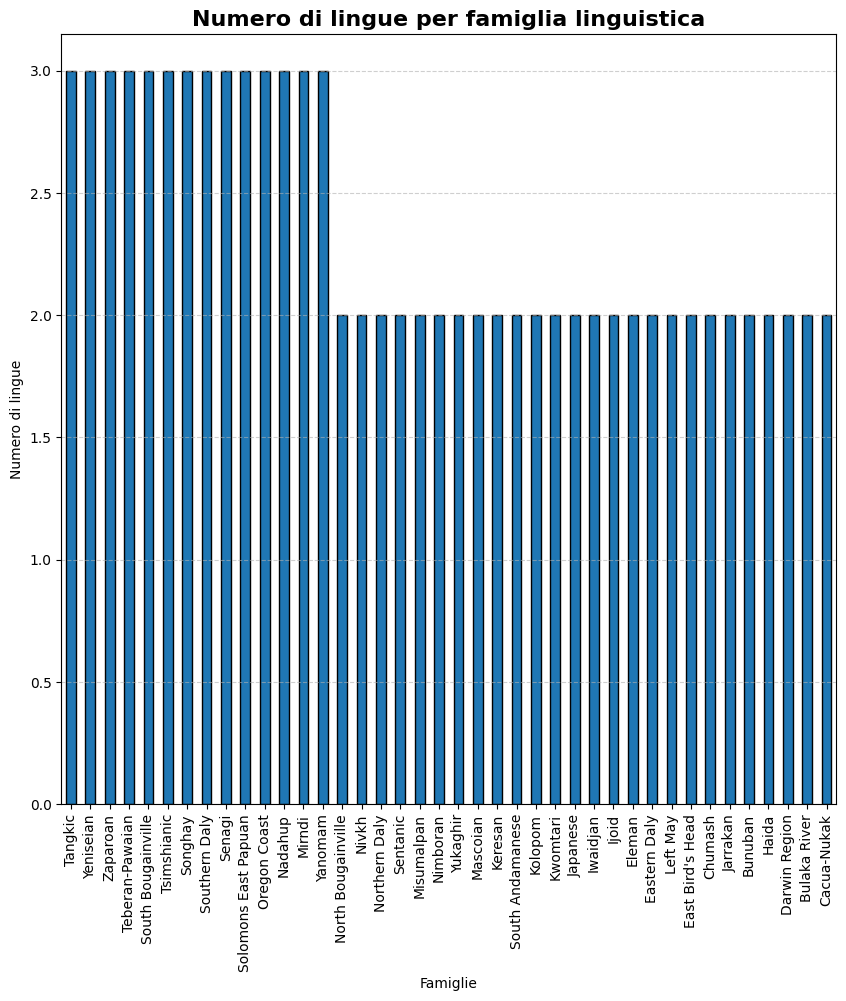

In [7]:
n_top= 119
qdf = df.copy().groupby("Family")["Language_ID"].nunique().sort_values(ascending=False)

# Questo perché era già presente un campo other nel dataset
previous_other = qdf.loc["other"]
qdf = qdf.drop(index="other")

languages_by_family = stats.pack_from(qdf, n_top).sort_values(ascending=False)
languages_by_family.at["Other"] += previous_other
languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family_chunks = stats.get_chunks(languages_by_family, (n_top + 1) // 3)

for chunk in languages_by_family_chunks:
    plotter.bar_plot(
        chunk,
        title="Numero di lingue per famiglia linguistica",
        xlabel="Famiglie",
        ylabel="Numero di lingue",
        annotate=False
    )

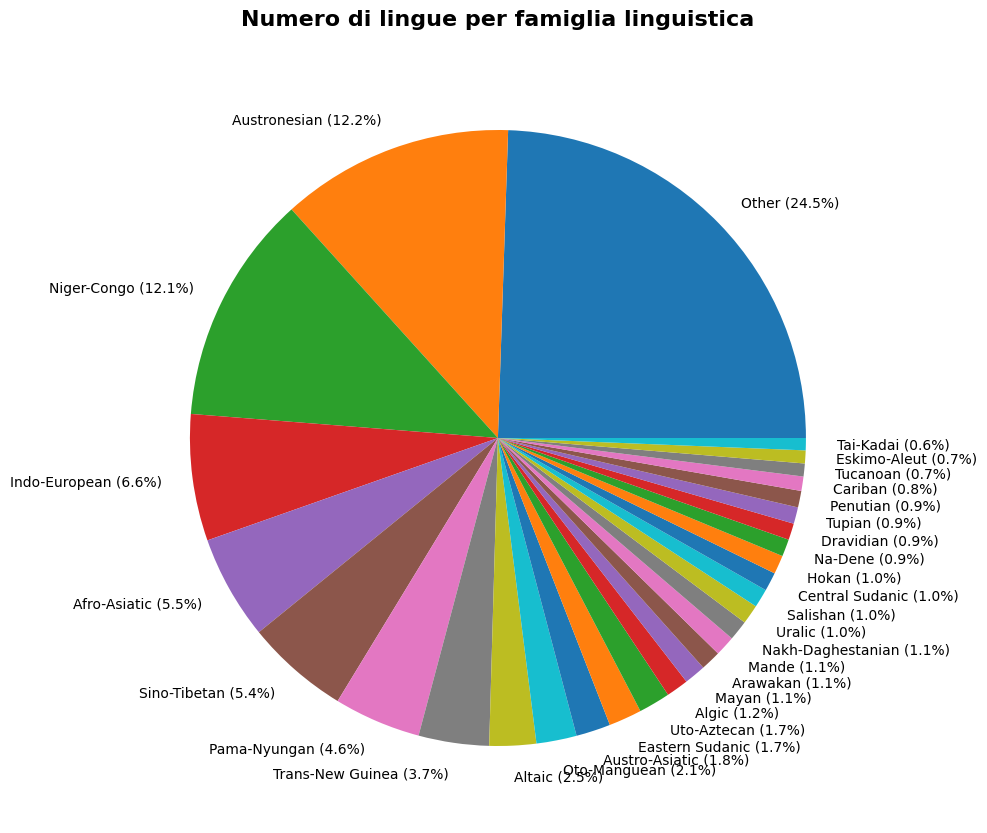

In [8]:
n_top= 29
qdf = df.copy().groupby("Family")["Language_ID"].nunique().sort_values(ascending=False)

# Questo perché era già presente un campo other nel dataset
previous_other = qdf.loc["other"]
qdf = qdf.drop(index="other")


languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family = stats.pack_from(qdf, n_top)
languages_by_family.at["Other"] += previous_other
languages_by_family = languages_by_family.sort_values(ascending=False)

plotter.pie_plot(
    languages_by_family,
    figsize=(10, 10),
    title="Numero di lingue per famiglia linguistica"
)

### Conteggio di famiglie per macroarea
La stessa analisi geografica può essere fatta a livello di famiglie linguistiche, un maggiore numero di famiglie linguistiche all'interno della stessa macroarea o dello stesso paese indica una maggiore divesità linguistica rispetto al mero numero di lingue diverse.

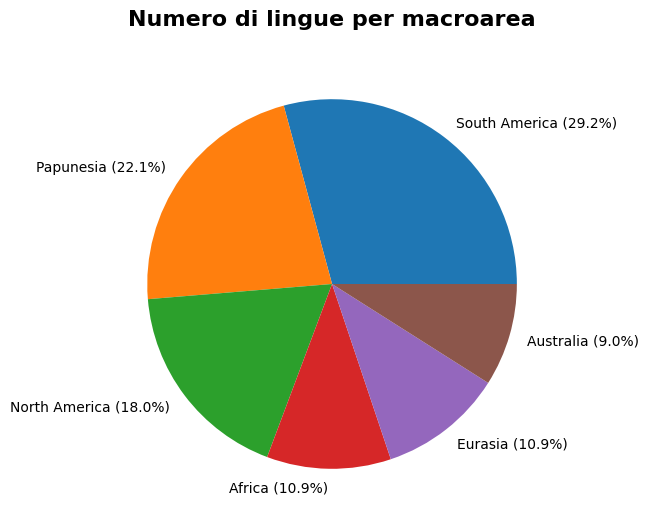

In [9]:
qdf = (
  df.copy()
  .groupby("Macroarea")["Family"]
  .nunique()
  .sort_values(ascending=False)
)

plotter.pie_plot(
    qdf,
    title="Numero di lingue per macroarea"
)

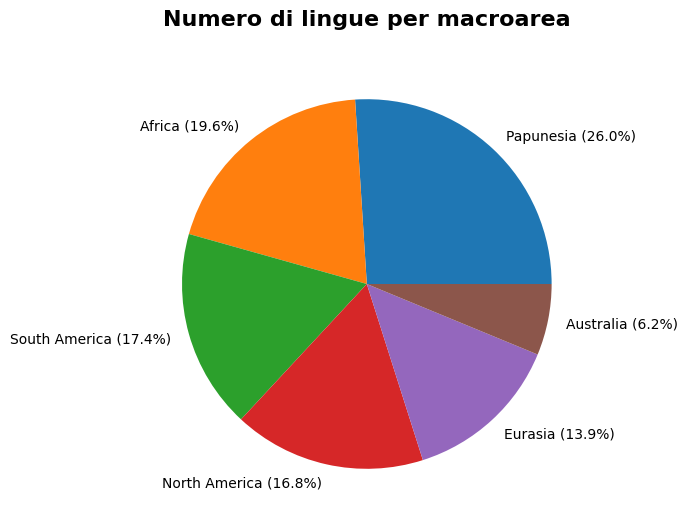

In [10]:
qdf = (
  df.copy()
  .groupby("Macroarea")["Genus"]
  .nunique()
  .sort_values(ascending=False)
)

plotter.pie_plot(
  qdf,
  title="Numero di lingue per macroarea"
)

### Conteggio di famiglie per Paese
La stessa analisi geografica può essere fatta a livello di famiglie linguistiche, un maggiore numero di famiglie linguistiche all'interno della stessa macroarea o dello stesso paese indica una maggiore divesità linguistica rispetto al mero numero di lingue diverse.

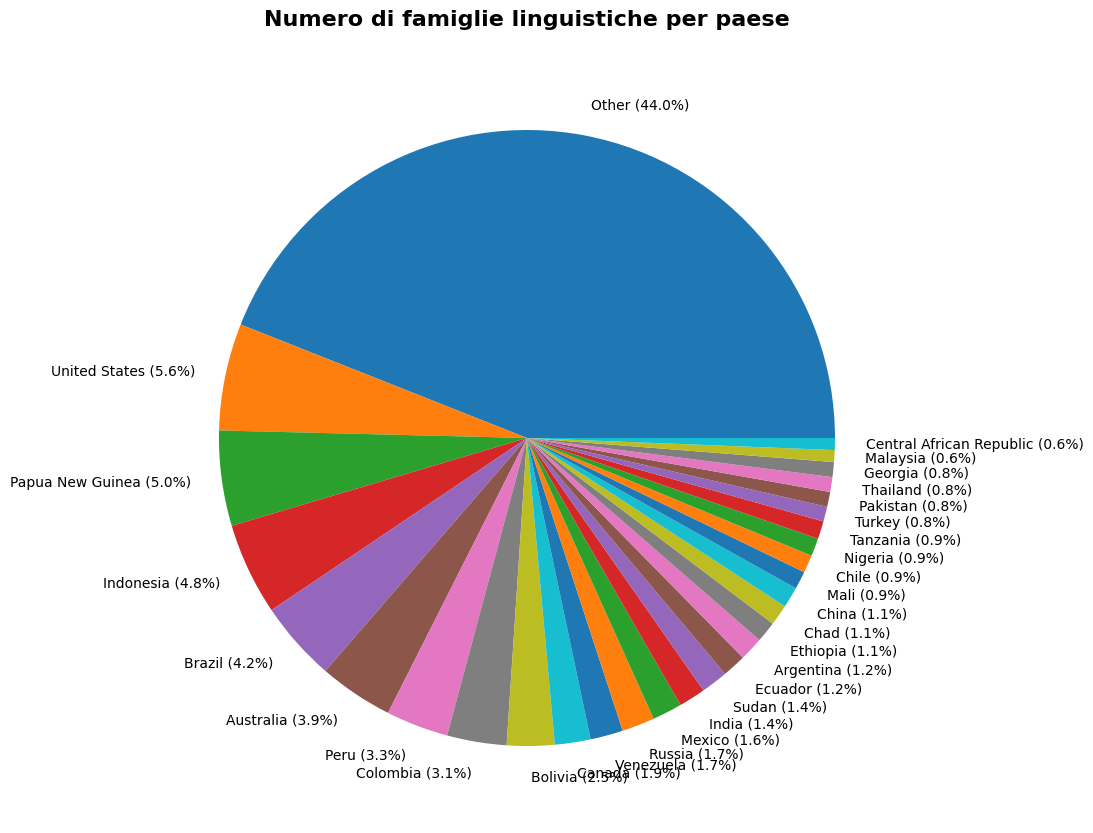

In [11]:
n_top= 29
qdf = df.copy().groupby("Country_Name")["Family"].nunique().sort_values(ascending=False)

languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family = stats.pack_from(qdf, n_top)
languages_by_family = languages_by_family.sort_values(ascending=False)

plotter.pie_plot(
    languages_by_family,
    figsize=(10, 10),
    title="Numero di famiglie linguistiche per paese"
)

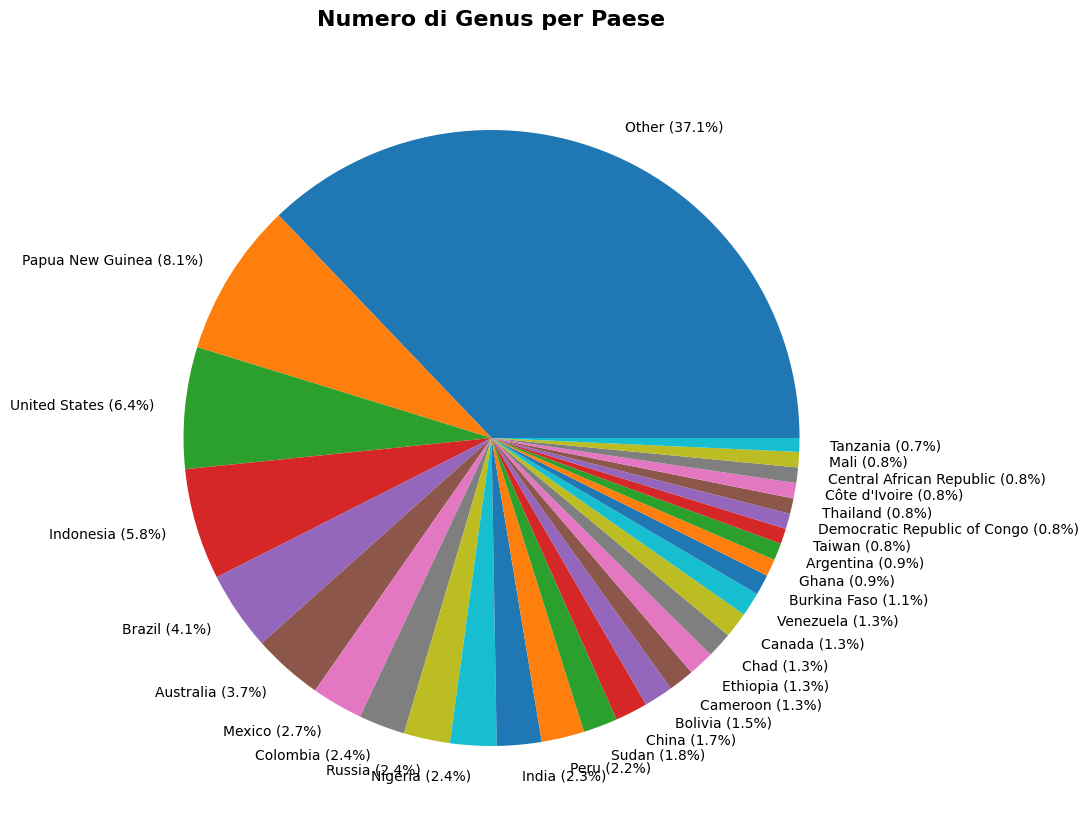

In [12]:
n_top= 29
qdf = df.copy().groupby("Country_Name")["Genus"].nunique().sort_values(ascending=False)

languages_by_family = languages_by_family.sort_values(ascending=False)
languages_by_family = stats.pack_from(qdf, n_top)
languages_by_family = languages_by_family.sort_values(ascending=False)

plotter.pie_plot(
    languages_by_family,
    figsize=(10, 10),
    title="Numero di Genus per Paese"
)

### Conto di lingue divise in famiglie per Paese

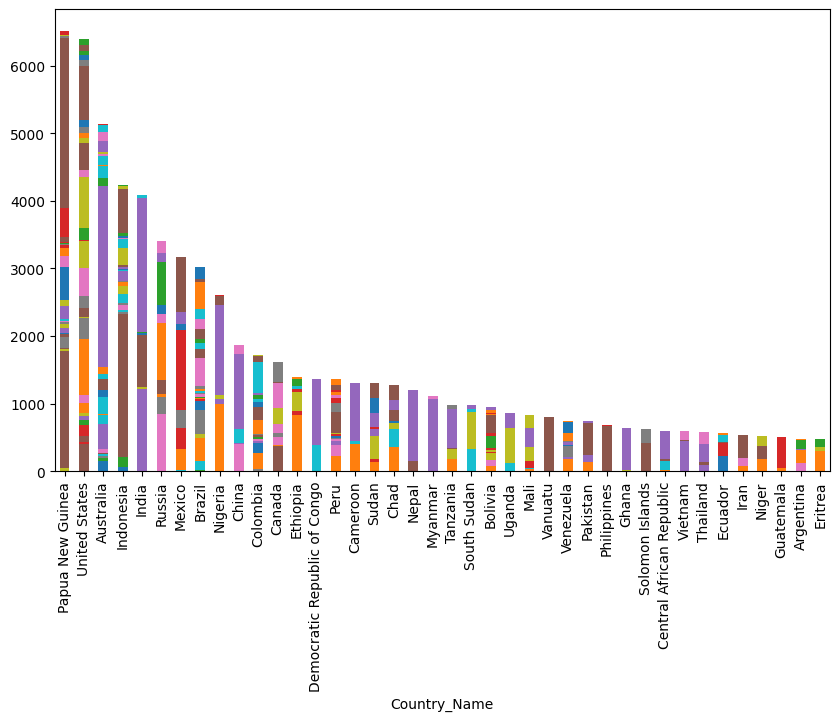

In [13]:

qdf = df.copy()
qdf = stats.filter_out(qdf, "Family", ["other"])
qdf = pd.crosstab(df["Country_Name"], df["Family"])

n_top = 40
qdf = qdf.assign(Total=qdf.sum(axis=1))


languages_by_family = qdf.sort_values("Total", ascending=False)
languages_by_family = languages_by_family.drop("Total", axis=1)

chunk = stats.get_chunks(languages_by_family, 40)[0]

plotter.stacked_bar_plot(chunk, legend=False)

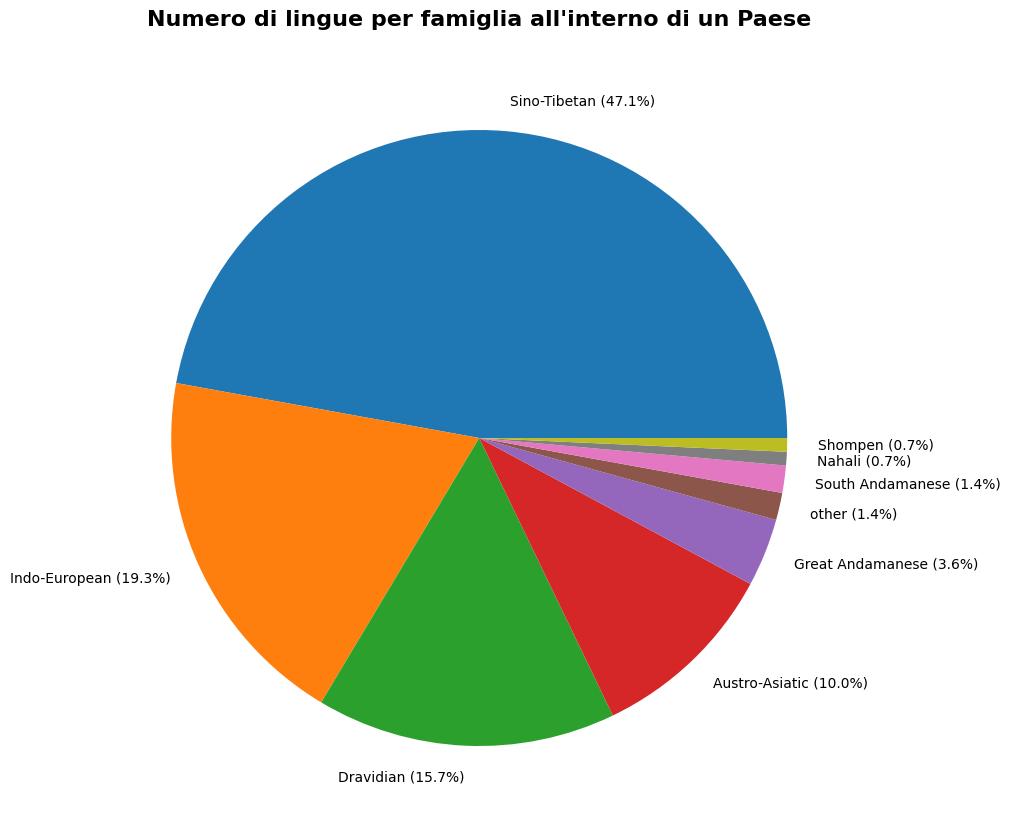

In [14]:
country_name="India"
qdf = df.copy()
qdf = stats.filter(qdf, "Country_Name", [country_name])
qdf = qdf.groupby("Family")["Language_ID"].nunique().sort_values(ascending=False)

plotter.pie_plot(
    qdf,
    figsize=(10, 10),
    title="Numero di lingue per famiglia all'interno di un Paese"
)

### Disposizione dei paesi in base alla diversità delle famiglie e diversità di lingue

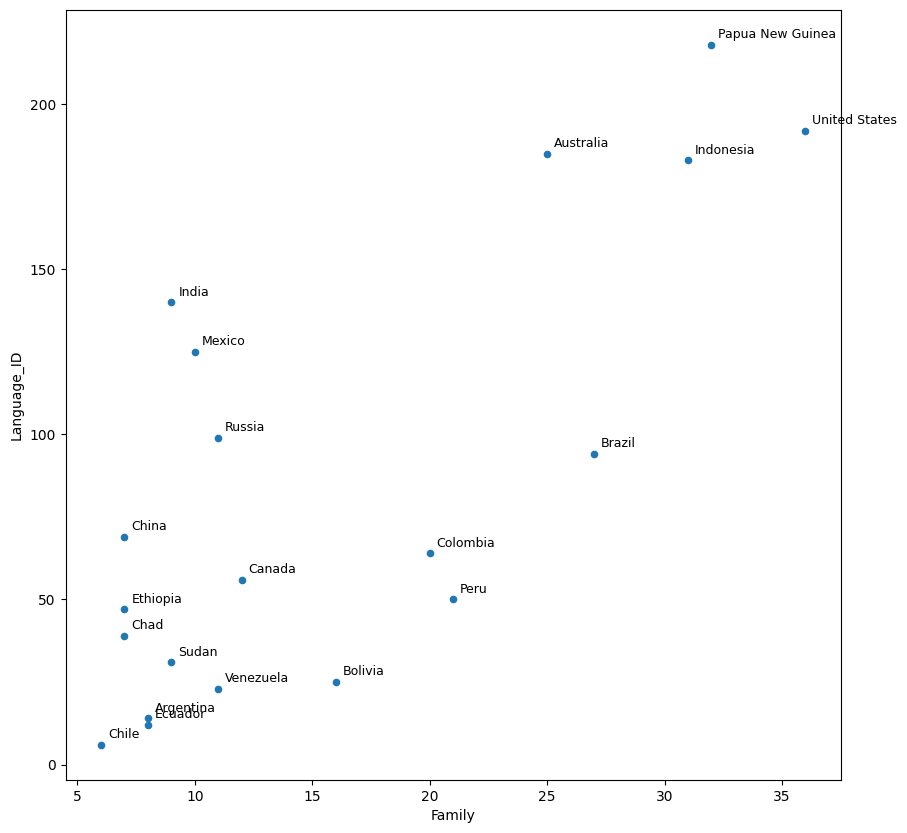

In [15]:
qdf = df.copy()
qdf = qdf.groupby("Country_Name")[["Family", "Language_ID"]].nunique().sort_values(by="Family", ascending=False).head(20)

plotter.scatter_plot(qdf, figsize=(10, 10), x="Family", y="Language_ID", annotate=True)